# FWI 3-Panel: GFDL-ESM4 vs MRI-ESM2-0 (Avg RH) vs MRI-ESM2-0 (Min RH)

Thailand region — area-weighted ensemble mean FWI across CMIP6 scenarios.

## 1. Imports

In [3]:
import os
import cftime
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import regionmask
from typing import List


## 2. Data Loading

In [5]:
BASE_CMIP6 = "/Volumes/jubjang/Jubjang/FWICMIP6"

# File paths — GFDL-ESM4 (single ensemble member per scenario)
files_GFDL = {
    "Historical": f"{BASE_CMIP6}/fwisa_ann_GFDL-ESM4_historical_r1i1p1f1_g025.nc",
    "SSP119":     f"{BASE_CMIP6}/fwisa_ann_GFDL-ESM4_ssp119_r1i1p1f1_g025.nc",
    "SSP126":     f"{BASE_CMIP6}/fwisa_ann_GFDL-ESM4_ssp126_r1i1p1f1_g025.nc",
    "SSP245":     f"{BASE_CMIP6}/fwisa_ann_GFDL-ESM4_ssp245_r1i1p1f1_g025.nc",
    "SSP370":     f"{BASE_CMIP6}/fwisa_ann_GFDL-ESM4_ssp370_r1i1p1f1_g025.nc",
    "SSP585":     f"{BASE_CMIP6}/fwisa_ann_GFDL-ESM4_ssp585_r1i1p1f1_g025.nc",
}

dataset_historical_GFDL_ESM4 = xr.open_mfdataset(files_GFDL["Historical"], combine='by_coords', engine='netcdf4')
dataset_SSP119_GFDL_ESM4     = xr.open_mfdataset(files_GFDL["SSP119"],     combine='by_coords', engine='netcdf4')
dataset_SSP126_GFDL_ESM4     = xr.open_mfdataset(files_GFDL["SSP126"],     combine='by_coords', engine='netcdf4')
dataset_SSP245_GFDL_ESM4     = xr.open_mfdataset(files_GFDL["SSP245"],     combine='by_coords', engine='netcdf4')
dataset_SSP370_GFDL_ESM4     = xr.open_mfdataset(files_GFDL["SSP370"],     combine='by_coords', engine='netcdf4')
dataset_SSP585_GFDL_ESM4     = xr.open_mfdataset(files_GFDL["SSP585"],     combine='by_coords', engine='netcdf4')


In [6]:
# MRI-ESM2-0 with average relative humidity (hurs)
# Historical: 12 ensemble members; SSP126/245/370/585: 5 members; SSP119/434/460/534-over: 1 member

valid_combinations_MRI_ESM2_0_avg_RH = [
    (1, 1), (1, 2), (1, 1000),
    (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1),
]
valid_combinations_ssp585_MRI_ESM2_0_avg_RH = [
    (1, 1), (1, 2), (2, 1), (3, 1), (4, 1), (5, 1),
]

files_historical_MRI_ESM2_0_avg_RH = [
    f"{BASE_CMIP6}/fwisa_ann_MRI-ESM2-0_historical_r{i}i{j}p1f1_g025.nc"
    for i, j in valid_combinations_MRI_ESM2_0_avg_RH
]
files_SSP119_MRI_ESM2_0_avg_RH = [f"{BASE_CMIP6}/fwisa_ann_MRI-ESM2-0_ssp119_r{i}i1p1f1_g025.nc" for i in range(1, 6)]
files_SSP126_MRI_ESM2_0_avg_RH = [f"{BASE_CMIP6}/fwisa_ann_MRI-ESM2-0_ssp126_r{i}i1p1f1_g025.nc" for i in range(1, 6)]
files_SSP245_MRI_ESM2_0_avg_RH = [f"{BASE_CMIP6}/fwisa_ann_MRI-ESM2-0_ssp245_r{i}i1p1f1_g025.nc" for i in range(1, 6)]
files_SSP370_MRI_ESM2_0_avg_RH = [f"{BASE_CMIP6}/fwisa_ann_MRI-ESM2-0_ssp370_r{i}i1p1f1_g025.nc" for i in range(1, 6)]
file_SSP434_MRI_ESM2_0_avg_RH  = f"{BASE_CMIP6}/fwisa_ann_MRI-ESM2-0_ssp434_r1i1p1f1_g025.nc"
file_SSP460_MRI_ESM2_0_avg_RH  = f"{BASE_CMIP6}/fwisa_ann_MRI-ESM2-0_ssp460_r1i1p1f1_g025.nc"
file_SSP534_MRI_ESM2_0_avg_RH  = f"{BASE_CMIP6}/fwisa_ann_MRI-ESM2-0_ssp534-over_r1i1p1f1_g025.nc"
files_SSP585_MRI_ESM2_0_avg_RH = [
    f"{BASE_CMIP6}/fwisa_ann_MRI-ESM2-0_ssp585_r{i}i{j}p1f1_g025.nc"
    for i, j in valid_combinations_ssp585_MRI_ESM2_0_avg_RH
]

def _load_dataset_list(file_list):
    """Open each file as a separate Dataset (one per ensemble member)."""
    return [xr.open_mfdataset(f, combine='by_coords', engine='netcdf4') for f in file_list]

datasets_historical_MRI_ESM2_0_avg_RH = _load_dataset_list(files_historical_MRI_ESM2_0_avg_RH)
dataset_SSP119_MRI_ESM2_0_avg_RH      = _load_dataset_list(files_SSP119_MRI_ESM2_0_avg_RH)
datasets_SSP126_MRI_ESM2_0_avg_RH     = _load_dataset_list(files_SSP126_MRI_ESM2_0_avg_RH)
datasets_SSP245_MRI_ESM2_0_avg_RH     = _load_dataset_list(files_SSP245_MRI_ESM2_0_avg_RH)
datasets_SSP370_MRI_ESM2_0_avg_RH     = _load_dataset_list(files_SSP370_MRI_ESM2_0_avg_RH)
dataset_SSP434_MRI_ESM2_0_avg_RH      = xr.open_mfdataset(file_SSP434_MRI_ESM2_0_avg_RH, combine='by_coords', engine='netcdf4')
dataset_SSP460_MRI_ESM2_0_avg_RH      = xr.open_mfdataset(file_SSP460_MRI_ESM2_0_avg_RH, combine='by_coords', engine='netcdf4')
dataset_SSP534_MRI_ESM2_0_avg_RH      = xr.open_mfdataset(file_SSP534_MRI_ESM2_0_avg_RH, combine='by_coords', engine='netcdf4')
datasets_SSP585_MRI_ESM2_0_avg_RH     = _load_dataset_list(files_SSP585_MRI_ESM2_0_avg_RH)


In [7]:
# MRI-ESM2-0 with minimum relative humidity (hursmin)
# Same ensemble structure as avg RH, but SSP434 is unavailable

BASE_MINRH = "/Volumes/jubjang/Jubjang/FWIminimumRH"

valid_combinations_MRI_ESM2_0_min_RH = [
    (1, 1), (1, 2), (1, 1000),
    (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1),
]
valid_combinations_ssp585_MRI_ESM2_0_min_RH = [
    (1, 1), (1, 2), (2, 1), (3, 1), (4, 1), (5, 1),
]

files_historical_MRI_ESM2_0_min_RH = [
    f"{BASE_MINRH}/fwisa_ann_MRI-ESM2-0_historical_r{i}i{j}p1f1_g025.nc"
    for i, j in valid_combinations_MRI_ESM2_0_min_RH
]
files_SSP119_MRI_ESM2_0_min_RH = [f"{BASE_MINRH}/fwisa_ann_MRI-ESM2-0_ssp119_r{i}i1p1f1_g025.nc" for i in range(1, 6)]
files_SSP126_MRI_ESM2_0_min_RH = [f"{BASE_MINRH}/fwisa_ann_MRI-ESM2-0_ssp126_r{i}i1p1f1_g025.nc" for i in range(1, 6)]
files_SSP245_MRI_ESM2_0_min_RH = [f"{BASE_MINRH}/fwisa_ann_MRI-ESM2-0_ssp245_r{i}i1p1f1_g025.nc" for i in range(1, 6)]
files_SSP370_MRI_ESM2_0_min_RH = [f"{BASE_MINRH}/fwisa_ann_MRI-ESM2-0_ssp370_r{i}i1p1f1_g025.nc" for i in range(1, 6)]
file_SSP460_MRI_ESM2_0_min_RH  = f"{BASE_MINRH}/fwisa_ann_MRI-ESM2-0_ssp460_r1i1p1f1_g025.nc"
file_SSP534_MRI_ESM2_0_min_RH  = f"{BASE_MINRH}/fwisa_ann_MRI-ESM2-0_ssp534-over_r1i1p1f1_g025.nc"
files_SSP585_MRI_ESM2_0_min_RH = [
    f"{BASE_MINRH}/fwisa_ann_MRI-ESM2-0_ssp585_r{i}i{j}p1f1_g025.nc"
    for i, j in valid_combinations_ssp585_MRI_ESM2_0_min_RH
]

datasets_historical_MRI_ESM2_0_min_RH = _load_dataset_list(files_historical_MRI_ESM2_0_min_RH)
datasets_SSP119_MRI_ESM2_0_min_RH     = _load_dataset_list(files_SSP119_MRI_ESM2_0_min_RH)
datasets_SSP126_MRI_ESM2_0_min_RH     = _load_dataset_list(files_SSP126_MRI_ESM2_0_min_RH)
datasets_SSP245_MRI_ESM2_0_min_RH     = _load_dataset_list(files_SSP245_MRI_ESM2_0_min_RH)
datasets_SSP370_MRI_ESM2_0_min_RH     = _load_dataset_list(files_SSP370_MRI_ESM2_0_min_RH)
dataset_SSP460_MRI_ESM2_0_min_RH      = xr.open_mfdataset(file_SSP460_MRI_ESM2_0_min_RH, combine='by_coords', engine='netcdf4')
dataset_SSP534_MRI_ESM2_0_min_RH      = xr.open_mfdataset(file_SSP534_MRI_ESM2_0_min_RH, combine='by_coords', engine='netcdf4')
datasets_SSP585_MRI_ESM2_0_min_RH     = _load_dataset_list(files_SSP585_MRI_ESM2_0_min_RH)


## 3. Grid-Cell Area Weights

In [9]:
# Spherical-Earth area per grid cell (km²) — GFDL-ESM4
R = 6_378_137  # Earth radius (m)

lon_GFDL_ESM4 = dataset_historical_GFDL_ESM4.coords['lon']
lat_GFDL_ESM4 = dataset_historical_GFDL_ESM4.coords['lat']

lon_rad_GFDL = np.radians(lon_GFDL_ESM4)
lat_rad_GFDL = np.radians(lat_GFDL_ESM4)
dlon = np.diff(lon_rad_GFDL)[0]
dlat = np.diff(lat_rad_GFDL).mean()

area_GFDL = np.zeros((len(lat_GFDL_ESM4), len(lon_GFDL_ESM4)))
for i in range(len(lat_GFDL_ESM4)):
    phi = lat_rad_GFDL[i]
    area_GFDL[i, :] = R**2 * dlon * (np.sin(phi + dlat / 2) - np.sin(phi - dlat / 2))
area_km2_GFDL_ESM4 = area_GFDL / 1e6


In [10]:
def compute_gridcell_area_km2_MRI_ESM2_0(ds_list, lon_name='lon', lat_name='lat'):
    """Spherical-Earth grid-cell area (km²) from the first dataset in the list."""
    lon = ds_list[0].coords[lon_name].values
    lat = ds_list[0].coords[lat_name].values
    lon_rad, lat_rad = np.radians(lon), np.radians(lat)
    dlon = np.diff(lon_rad)[0]
    dlat = np.diff(lat_rad).mean()
    area = np.zeros((len(lat), len(lon)))
    for i in range(len(lat)):
        phi = lat_rad[i]
        area[i, :] = R**2 * dlon * (np.sin(phi + dlat / 2) - np.sin(phi - dlat / 2))
    return area / 1e6

area_km2_MRI_ESM2_0_avg_RH = compute_gridcell_area_km2_MRI_ESM2_0(datasets_historical_MRI_ESM2_0_avg_RH)
area_km2_MRI_ESM2_0_min_RH = compute_gridcell_area_km2_MRI_ESM2_0(datasets_historical_MRI_ESM2_0_min_RH)

# Shared 2.5° lat/lon grid (72×144)
lat = np.linspace(-88.75, 88.75, 72)
lon = np.linspace(1.25, 358.75, 144)

def _make_areacella(area_km2):
    da = xr.DataArray(area_km2, dims=['lat', 'lon'], coords={'lat': lat, 'lon': lon}, name='area')
    return xr.Dataset({'area': da})

areacella_MRI_ESM2_0_avg_RH = _make_areacella(area_km2_MRI_ESM2_0_avg_RH)
areacella_MRI_ESM2_0_min_RH = _make_areacella(area_km2_MRI_ESM2_0_min_RH)
areacella_GFDL_ESM4         = _make_areacella(area_km2_GFDL_ESM4)


## 4. Dataset Grouping and Regional Statistics

In [12]:
# GFDL-ESM4: scenario list (same order used for plotting)
datasets_all_scenarios_GFDL_ESM4 = [
    dataset_historical_GFDL_ESM4,
    dataset_SSP119_GFDL_ESM4,
    dataset_SSP126_GFDL_ESM4,
    dataset_SSP245_GFDL_ESM4,
    dataset_SSP370_GFDL_ESM4,
    dataset_SSP585_GFDL_ESM4,
]
labels_all_scenarios_GFDL_ESM4 = [
    'Historical', 'SSP1-1.9', 'SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5',
]

# Thailand bounding box
thailand_lat_range = slice(5.5, 20.5)
thailand_lon_range = slice(97.5, 105.5)

areacella_th_MRI_ESM2_0_avg_RH = areacella_MRI_ESM2_0_avg_RH.sel(lat=thailand_lat_range, lon=thailand_lon_range)
areacella_th_MRI_ESM2_0_min_RH = areacella_MRI_ESM2_0_min_RH.sel(lat=thailand_lat_range, lon=thailand_lon_range)


In [13]:
def _compute_ssp_mean_from_files(file_list, lat_range, lon_range, area_weights):
    """
    Load files, select the Thailand region, and compute the area-weighted
    ensemble mean and standard deviation over lat/lon and ensemble members.
    """
    members = [xr.open_dataset(f, engine='netcdf4') for f in file_list]
    ssp_data = xr.concat(members, dim='ensemble')
    ssp_th   = ssp_data.sel(lat=lat_range, lon=lon_range)
    spatial  = ssp_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])
    return spatial.mean(dim='ensemble'), spatial.std(dim='ensemble')

kw_avg = dict(lat_range=thailand_lat_range, lon_range=thailand_lon_range,
              area_weights=areacella_th_MRI_ESM2_0_avg_RH)

historical_mean_th_MRI_avg, historical_std_th_MRI_avg = _compute_ssp_mean_from_files(files_historical_MRI_ESM2_0_avg_RH, **kw_avg)
ssp119_mean_th_MRI_avg,     ssp119_std_th_MRI_avg     = _compute_ssp_mean_from_files(files_SSP119_MRI_ESM2_0_avg_RH,       **kw_avg)
ssp126_mean_th_MRI_avg,     ssp126_std_th_MRI_avg     = _compute_ssp_mean_from_files(files_SSP126_MRI_ESM2_0_avg_RH,        **kw_avg)
ssp245_mean_th_MRI_avg,     ssp245_std_th_MRI_avg     = _compute_ssp_mean_from_files(files_SSP245_MRI_ESM2_0_avg_RH,        **kw_avg)
ssp370_mean_th_MRI_avg,     ssp370_std_th_MRI_avg     = _compute_ssp_mean_from_files(files_SSP370_MRI_ESM2_0_avg_RH,        **kw_avg)
ssp434_mean_th_MRI_avg,     ssp434_std_th_MRI_avg     = _compute_ssp_mean_from_files([file_SSP434_MRI_ESM2_0_avg_RH],       **kw_avg)
ssp460_mean_th_MRI_avg,     ssp460_std_th_MRI_avg     = _compute_ssp_mean_from_files([file_SSP460_MRI_ESM2_0_avg_RH],       **kw_avg)
ssp534_mean_th_MRI_avg,     ssp534_std_th_MRI_avg     = _compute_ssp_mean_from_files([file_SSP534_MRI_ESM2_0_avg_RH],       **kw_avg)
ssp585_mean_th_MRI_avg,     ssp585_std_th_MRI_avg     = _compute_ssp_mean_from_files(files_SSP585_MRI_ESM2_0_avg_RH,        **kw_avg)


In [14]:
def concatenate_ensemble(dsets):
    """Concatenate a list of Datasets along a new 'ensemble' dimension."""
    if isinstance(dsets, (xr.Dataset, xr.DataArray)):
        return dsets if 'ensemble' in dsets.dims else dsets.expand_dims(ensemble=[0])
    return xr.concat(dsets, dim='ensemble')

# Concatenate ensemble members for min RH scenarios
datasets_historical_MRI_ESM2_0_min_RH = concatenate_ensemble(datasets_historical_MRI_ESM2_0_min_RH)
datasets_SSP119_MRI_ESM2_0_min_RH     = concatenate_ensemble(datasets_SSP119_MRI_ESM2_0_min_RH)
datasets_SSP126_MRI_ESM2_0_min_RH     = concatenate_ensemble(datasets_SSP126_MRI_ESM2_0_min_RH)
datasets_SSP245_MRI_ESM2_0_min_RH     = concatenate_ensemble(datasets_SSP245_MRI_ESM2_0_min_RH)
datasets_SSP370_MRI_ESM2_0_min_RH     = concatenate_ensemble(datasets_SSP370_MRI_ESM2_0_min_RH)
datasets_SSP460_MRI_ESM2_0_min_RH     = concatenate_ensemble([dataset_SSP460_MRI_ESM2_0_min_RH])
datasets_SSP534_MRI_ESM2_0_min_RH     = concatenate_ensemble([dataset_SSP534_MRI_ESM2_0_min_RH])
datasets_SSP585_MRI_ESM2_0_min_RH     = concatenate_ensemble(datasets_SSP585_MRI_ESM2_0_min_RH)

def process_ssp_data_th(ssp_data, lat_range, lon_range, area_weights):
    """
    Select the Thailand region from a pre-concatenated Dataset and compute
    the area-weighted ensemble mean and standard deviation.
    """
    ssp_th  = ssp_data.sel(lat=lat_range, lon=lon_range)
    spatial = ssp_th.weighted(area_weights['area']).mean(dim=['lat', 'lon'])
    return spatial.mean(dim='ensemble'), spatial.std(dim='ensemble')

kw_min = dict(lat_range=thailand_lat_range, lon_range=thailand_lon_range,
              area_weights=areacella_th_MRI_ESM2_0_min_RH)

historical_mean_th_MRI_min, historical_std_th_MRI_min = process_ssp_data_th(datasets_historical_MRI_ESM2_0_min_RH, **kw_min)
ssp119_mean_th_MRI_min,     ssp119_std_th_MRI_min     = process_ssp_data_th(datasets_SSP119_MRI_ESM2_0_min_RH,     **kw_min)
ssp126_mean_th_MRI_min,     ssp126_std_th_MRI_min     = process_ssp_data_th(datasets_SSP126_MRI_ESM2_0_min_RH,     **kw_min)
ssp245_mean_th_MRI_min,     ssp245_std_th_MRI_min     = process_ssp_data_th(datasets_SSP245_MRI_ESM2_0_min_RH,     **kw_min)
ssp370_mean_th_MRI_min,     ssp370_std_th_MRI_min     = process_ssp_data_th(datasets_SSP370_MRI_ESM2_0_min_RH,     **kw_min)
ssp460_mean_th_MRI_min,     ssp460_std_th_MRI_min     = process_ssp_data_th(datasets_SSP460_MRI_ESM2_0_min_RH,     **kw_min)
ssp534_mean_th_MRI_min,     ssp534_std_th_MRI_min     = process_ssp_data_th(datasets_SSP534_MRI_ESM2_0_min_RH,     **kw_min)
ssp585_mean_th_MRI_min,     ssp585_std_th_MRI_min     = process_ssp_data_th(datasets_SSP585_MRI_ESM2_0_min_RH,     **kw_min)


In [15]:
# Ordered lists passed to the plot function
ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH = [
    historical_mean_th_MRI_avg, ssp119_mean_th_MRI_avg, ssp126_mean_th_MRI_avg,
    ssp245_mean_th_MRI_avg,     ssp370_mean_th_MRI_avg, ssp434_mean_th_MRI_avg,
    ssp460_mean_th_MRI_avg,     ssp534_mean_th_MRI_avg, ssp585_mean_th_MRI_avg,
]
ensemble_stds_th_all_scenarios_MRI_ESM2_0_avg_RH = [
    historical_std_th_MRI_avg,  ssp119_std_th_MRI_avg,  ssp126_std_th_MRI_avg,
    ssp245_std_th_MRI_avg,      ssp370_std_th_MRI_avg,  ssp434_std_th_MRI_avg,
    ssp460_std_th_MRI_avg,      ssp534_std_th_MRI_avg,  ssp585_std_th_MRI_avg,
]

ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH = [
    historical_mean_th_MRI_min, ssp119_mean_th_MRI_min, ssp126_mean_th_MRI_min,
    ssp245_mean_th_MRI_min,     ssp370_mean_th_MRI_min, ssp460_mean_th_MRI_min,
    ssp534_mean_th_MRI_min,     ssp585_mean_th_MRI_min,
]
ensemble_stds_th_all_scenarios_MRI_ESM2_0_min_RH = [
    historical_std_th_MRI_min,  ssp119_std_th_MRI_min,  ssp126_std_th_MRI_min,
    ssp245_std_th_MRI_min,      ssp370_std_th_MRI_min,  ssp460_std_th_MRI_min,
    ssp534_std_th_MRI_min,      ssp585_std_th_MRI_min,
]


## 5. Plotting Utilities

In [17]:
# ── Palette ─────────────────────────────────────────────────────────────────
color_blind_palette = {
    "Historical": "#000000",
    "SSP119":     "#E69F00",
    "SSP126":     "#56B4E9",
    "SSP245":     "#009E73",
    "SSP370":     "#882255",
    "SSP434":     "#E6D600",
    "SSP460":     "#D55E00",
    "SSP534":     "#0072B2",
    "SSP585":     "#CC79A7",
}

SHORT_LABELS = {
    "Historical": "Historical",
    "SSP119": "SSP1-1.9",  "SSP126": "SSP1-2.6",
    "SSP245": "SSP2-4.5",  "SSP370": "SSP3-7.0",
    "SSP434": "SSP4-3.4",  "SSP460": "SSP4-6.0",
    "SSP534": "SSP5-3.4",  "SSP585": "SSP5-8.5",
}

LONG_LABELS = {
    "Historical": 'Historical to Present (1850\u20132015)',
    "SSP119":     'SSP1-1.9 (\u201cSustainability \u2014 Very Low Emissions\u201d)',
    "SSP126":     'SSP1-2.6 (\u201cSustainability \u2014 Low Emissions\u201d)',
    "SSP245":     'SSP2-4.5 (\u201cMiddle of the Road \u2014 Moderate Emissions\u201d)',
    "SSP370":     'SSP3-7.0 (\u201cRegional Rivalry \u2014 High Emissions\u201d)',
    "SSP434":     'SSP4-3.4 (\u201cInequality \u2014 Intermediate Emissions\u201d)',
    "SSP460":     'SSP4-6.0 (\u201cInequality \u2014 High Emissions\u201d)',
    "SSP534":     'SSP5-3.4 (\u201cFossil-Fueled Development \u2014 Moderate Emissions\u201d)',
    "SSP585":     'SSP5-8.5 (\u201cFossil-Fueled Development \u2014 High Emissions\u201d)',
}

# ── Canonical scenario ordering ───────────────────────────────────────────────
SCENARIO_ORDER = [
    "Historical", "SSP119", "SSP126", "SSP245", "SSP370",
    "SSP434", "SSP460", "SSP534", "SSP585",
]

# ── Label / colour helpers ────────────────────────────────────────────────────
def _scenario_key_from_label(label: str):
    if not label:
        return None
    lc = label.lower().replace(' ', '').replace('-', '').replace('.', '')
    if 'historical' in lc:               return 'Historical'
    if 'ssp119' in lc or 'ssp119' in lc: return 'SSP119'
    if 'ssp126' in lc:                   return 'SSP126'
    if 'ssp245' in lc:                   return 'SSP245'
    if 'ssp370' in lc:                   return 'SSP370'
    if 'ssp434' in lc:                   return 'SSP434'
    if 'ssp460' in lc:                   return 'SSP460'
    if 'ssp534' in lc:                   return 'SSP534'
    if 'ssp585' in lc:                   return 'SSP585'
    return None

def _long_label_for(label: str) -> str:
    return LONG_LABELS.get(_scenario_key_from_label(label), label or '')

def _color_for_label(label: str) -> str:
    return color_blind_palette.get(_scenario_key_from_label(label), '#000000')

def _scenario_rank(label: str) -> int:
    key = _scenario_key_from_label(label)
    try:    return SCENARIO_ORDER.index(key)
    except: return 10**9

def _present_keys_in_order(labels: List[str]) -> List[str]:
    present = {_scenario_key_from_label(l) for l in labels if l}
    return [k for k in SCENARIO_ORDER if k in present]

# ── Time helpers ──────────────────────────────────────────────────────────────
def _to_datetime_index(time_values):
    """Convert xarray/cftime time coordinate to numpy datetime64."""
    if len(time_values) == 0:
        return np.array([], dtype='datetime64[ns]')
    try:
        if isinstance(time_values[0], (cftime.DatetimeNoLeap, cftime.DatetimeGregorian,
                                       cftime.DatetimeProlepticGregorian)):
            return np.array([pd.Timestamp(str(t)) for t in time_values])
    except Exception:
        pass
    return pd.to_datetime(time_values)

def _apply_rolling(ts: xr.DataArray, window):
    """Centered rolling mean over the 'time' dimension."""
    if not window or window <= 1:
        return ts
    ts = ts.sortby('time')
    return ts.rolling(time=window, center=True, min_periods=max(1, window // 2)).mean()

# ── Spatial helpers ───────────────────────────────────────────────────────────
def _spatial_weighted_mean_fwisa(ds_or_da, area_ds: xr.Dataset) -> xr.DataArray:
    """Area-weighted spatial mean of 'fwisa' over lat/lon."""
    da = ds_or_da['fwisa'] if isinstance(ds_or_da, xr.Dataset) else ds_or_da
    area = area_ds['area'].sel(lat=da.lat, lon=da.lon, method='nearest')
    return da.weighted(area).mean(dim=['lat', 'lon'])


## 6. Figure — Area-Weighted FWI (Thailand)

In [19]:
def _plot_panel(ax, time_list, series_list, labels_list):
    """Plot time-series lines sorted in canonical SSP order."""
    triples = sorted(zip(time_list, series_list, labels_list),
                     key=lambda tup: _scenario_rank(tup[2]))
    for t, y, lbl in triples:
        ax.plot(t, y, label=_long_label_for(lbl), linewidth=1.0,
                alpha=0.95, color=_color_for_label(lbl))
    ax.grid(True, alpha=0.4)
    ax.tick_params(labelsize=8)  # Elsevier min font = 8 pt

def set_split_title(ax, left, right="", fontsize=9):
    ax.set_title(left, loc="left", fontsize=fontsize)
    if right:
        ax.text(1.0, 1.02, right, transform=ax.transAxes,
                ha="right", va="bottom", fontsize=fontsize)


def plot_fwi_3panel_without_caption(
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    areacella_GFDL_ESM4,
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    labels_MRI_avg,
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    labels_MRI_min,
    output_path,
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    smooth_window=None,
):
    """
    2x2 figure layout (Elsevier double-column: 190 mm = 7.48 in, min font 8 pt):
      [0,0] GFDL-ESM4            [0,1] MRI-ESM2-0 Avg RH
      [1,0] MRI-ESM2-0 Min RH   [1,1] SSP legend
    """
    # 7.48 in = 190 mm (double column); height 3.5 in gives ~1.6 in per row
    fig, axes = plt.subplots(2, 2, figsize=(7.48, 4.0), sharey=True)
    axG, axMRI, axMIN, axSSP = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]

    # [0,0] GFDL-ESM4
    time_G, series_G = [], []
    for ds, lbl in zip(datasets_all_scenarios_GFDL_ESM4, labels_all_scenarios_GFDL_ESM4):
        ts = _apply_rolling(_spatial_weighted_mean_fwisa(ds.sel(lat=thailand_lat_range, lon=thailand_lon_range), areacella_GFDL_ESM4), smooth_window)
        time_G.append(_to_datetime_index(ts["time"].values))
        series_G.append(ts.values)
    _plot_panel(axG, time_G, series_G, labels_all_scenarios_GFDL_ESM4)
    set_split_title(axG, "a) GFDL ESM4.1 Avg RH")
    axG.set_ylabel("FWI", fontsize=9)

    # [0,1] MRI-ESM2-0 Avg RH (hurs)
    time_M, series_M = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH, labels_MRI_avg):
        ts = mean_da["fwisa"] if isinstance(mean_da, xr.Dataset) else mean_da
        if {"lat", "lon"}.issubset(set(getattr(ts, "dims", []))) and areacella_MRI_ESM2_0_avg_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_avg_RH)
        if "ensemble" in getattr(ts, "dims", []):
            ts = ts.mean(dim="ensemble")
        ts = _apply_rolling(ts, smooth_window)
        time_M.append(_to_datetime_index(ts["time"].values))
        series_M.append(ts.values)
    _plot_panel(axMRI, time_M, series_M, labels_MRI_avg)
    set_split_title(axMRI, "b) MRI ESM2.0 Avg RH")

    # [1,0] MRI-ESM2-0 Min RH (hursmin)
    time_N, series_N = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH, labels_MRI_min):
        ts = mean_da["fwisa"] if isinstance(mean_da, xr.Dataset) else mean_da
        if {"lat", "lon"}.issubset(set(getattr(ts, "dims", []))) and areacella_MRI_ESM2_0_min_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_min_RH)
        if "ensemble" in getattr(ts, "dims", []):
            ts = ts.mean(dim="ensemble")
        ts = _apply_rolling(ts, smooth_window)
        time_N.append(_to_datetime_index(ts["time"].values))
        series_N.append(ts.values)
    _plot_panel(axMIN, time_N, series_N, labels_MRI_min)
    set_split_title(axMIN, "c) MRI ESM2.0 Min RH")
    axMIN.set_ylabel("FWI", fontsize=9)

    # [1,1] Legend panel
    axSSP.axis("off")
    all_labels = list(labels_all_scenarios_GFDL_ESM4) + list(labels_MRI_avg) + list(labels_MRI_min)
    present_keys = _present_keys_in_order(all_labels)
    handles = [
        axSSP.plot([], [], color=color_blind_palette.get(k, "#000000"), linewidth=1.5)[0]
        for k in present_keys
    ]
    legend_labels = [SHORT_LABELS.get(k, k) for k in present_keys]
    axSSP.legend(handles, legend_labels, loc="upper left", frameon=False, fontsize=8, ncol=1)

    # Shared x-axis formatting
    xmin, xmax = pd.Timestamp("1850-01-01"), pd.Timestamp("2100-12-31")
    years      = [1850, 1900, 1950, 2000, 2050, 2100]
    year_ticks = [pd.Timestamp(f"{y}-01-01") for y in years]
    for ax in [axG, axMRI, axMIN]:
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(bottom=15)
        ax.set_xticks(year_ticks)
        ax.set_xticklabels([str(y) for y in years], fontsize=8)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight", transparent=False)
    plt.show()


# ── Scenario labels per model ─────────────────────────────────────────────────
GFDL_long_labels = [
    LONG_LABELS["Historical"], LONG_LABELS["SSP119"], LONG_LABELS["SSP126"],
    LONG_LABELS["SSP245"],     LONG_LABELS["SSP370"], LONG_LABELS["SSP585"],
]
MRI_avg_long_labels = [
    LONG_LABELS["Historical"], LONG_LABELS["SSP119"], LONG_LABELS["SSP126"],
    LONG_LABELS["SSP245"],     LONG_LABELS["SSP370"], LONG_LABELS["SSP434"],
    LONG_LABELS["SSP460"],     LONG_LABELS["SSP534"], LONG_LABELS["SSP585"],
]
MRI_min_long_labels = [
    LONG_LABELS["Historical"], LONG_LABELS["SSP119"], LONG_LABELS["SSP126"],
    LONG_LABELS["SSP245"],     LONG_LABELS["SSP370"], LONG_LABELS["SSP460"],
    LONG_LABELS["SSP534"],     LONG_LABELS["SSP585"],
]


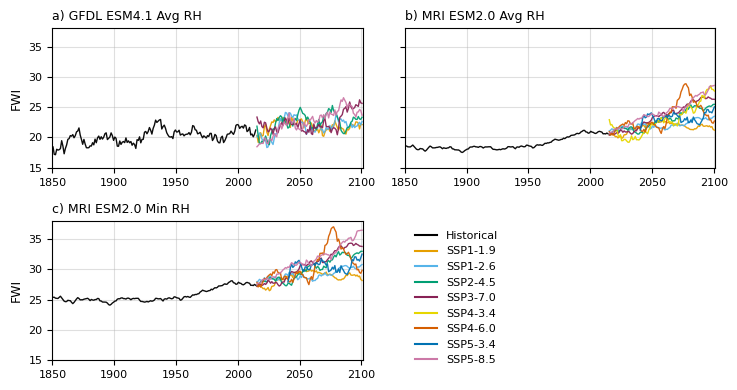

In [20]:
os.makedirs('FIG', exist_ok=True)

plot_fwi_3panel_without_caption(
    datasets_all_scenarios_GFDL_ESM4,
    GFDL_long_labels,
    areacella_GFDL_ESM4,
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    MRI_avg_long_labels,
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    MRI_min_long_labels,
    output_path='FIG/FWI_all_models_2x2_square.png',
    smooth_window=10,
)


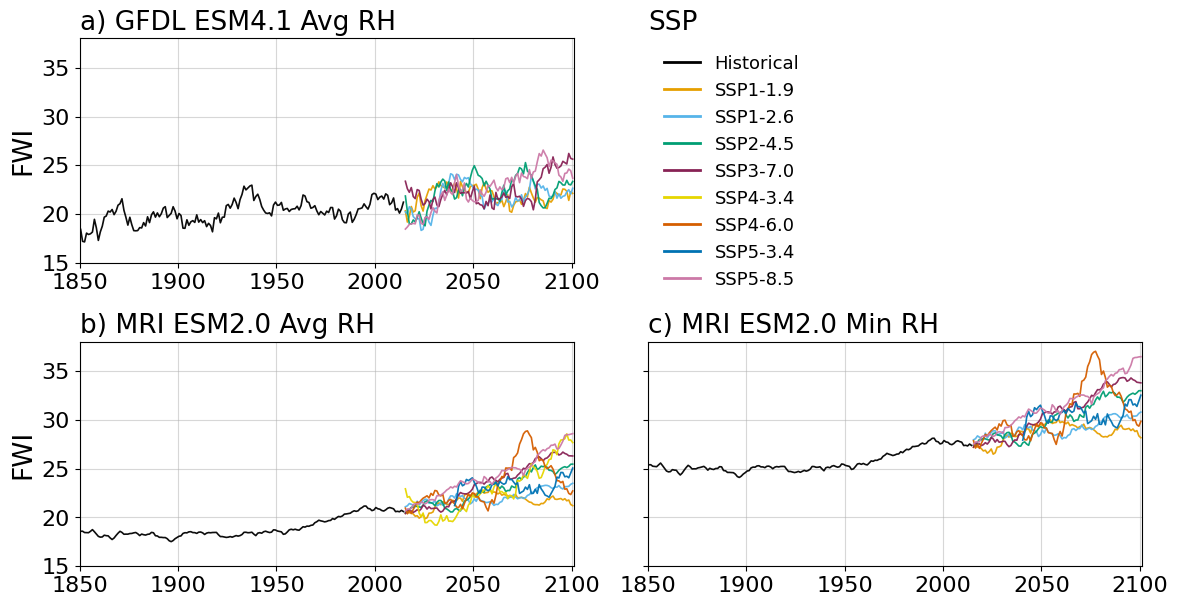

In [21]:
def _plot_panel_like_gfdl(ax, time_list, series_list, labels_list):
    """
    Plot multiple time series on one axis using consistent scenario colors and long legend labels.
    The lines are sorted by canonical SSP order.
    """
    triples = list(zip(time_list, series_list, labels_list))
    triples.sort(key=lambda tup: _scenario_rank(tup[2]))

    for t, y, lbl in triples:
        long_lbl = _long_label_for(lbl)
        color = _color_for_label(lbl)
        ax.plot(t, y, label=long_lbl, linewidth=1.2, alpha=0.95, color=color)
    ax.grid(True, alpha=0.5)
    ax.tick_params(labelsize=16)

def set_split_title(ax, left, right, fontsize=19):
    ax.set_title(left, loc="left", fontsize=fontsize)  # left side
    ax.text(1.0, 1.02, right, transform=ax.transAxes,  # right side
            ha="right", va="bottom", fontsize=fontsize)


def plot_fwi_3panel_without_caption(
    # --- REQUIRED ---
    datasets_all_scenarios_GFDL_ESM4,
    labels_all_scenarios_GFDL_ESM4,
    areacella_GFDL_ESM4,
    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    labels_MRI_avg,
    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    labels_MRI_min,
    output_path,
    # --- OPTIONAL ---
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    title_left="GFDL-ESM4",
    title_mid="MRI-ESM2-0 hurs",
    title_right="MRI-ESM2-0 hursmin",
    title_ssp="SSP",
    smooth_window=None
):
    """
    2x2 layout (all square panels):
      [0,0] GFDL
      [0,1] MRI (hurs / avg RH)
      [1,0] MRI (hursmin / min RH)
      [1,1] SSP legend panel
    """
    fig, axes = plt.subplots(2, 2, figsize=(7.48, 3.3), sharey=True)
    axG   = axes[0, 0]   # top-left
    axSSP = axes[0, 1]   # top-right
    
    axMRI = axes[1, 0]   # bottom-left (Avg RH)
    axMIN = axes[1, 1]   # bottom-right (Min RH)

   
    # Make each subplot box square (not data aspect)
    # for ax in [axG, axMRI, axMIN, axSSP]:
    #     if hasattr(ax, "set_box_aspect"):
    #         ax.set_box_aspect(1)

    # ----- [0,0] GFDL -----
    time_G, series_G = [], []
    for ds, lbl in zip(datasets_all_scenarios_GFDL_ESM4, labels_all_scenarios_GFDL_ESM4):
        ts = _spatial_weighted_mean_fwisa(ds.sel(lat=thailand_lat_range, lon=thailand_lon_range), areacella_GFDL_ESM4)
        ts = _apply_rolling(ts, smooth_window)
        t = _to_datetime_index(ts["time"].values)
        time_G.append(t); series_G.append(ts.values)
    _plot_panel_like_gfdl(axG, time_G, series_G, labels_all_scenarios_GFDL_ESM4)
    set_split_title(axG, "a) GFDL ESM4.1 Avg RH", "", fontsize=19)
    # axG.set_xlabel("Date", fontsize=9)
    axG.set_ylabel("FWI", fontsize=19)

    # ----- [0,1] MRI avg RH (hurs) -----
    time_M, series_M = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH, labels_MRI_avg):
        ts = (mean_da["fwisa"] if isinstance(mean_da, xr.Dataset) else mean_da)

        if set(["lat", "lon"]).issubset(getattr(ts, "dims", [])) and areacella_MRI_ESM2_0_avg_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_avg_RH)

        if "ensemble" in getattr(ts, "dims", []):
            ts = ts.mean(dim="ensemble")

        ts = _apply_rolling(ts, smooth_window)
        t = _to_datetime_index(ts["time"].values)
        time_M.append(t); series_M.append(ts.values)

    _plot_panel_like_gfdl(axMRI, time_M, series_M, labels_MRI_avg)
    axMRI.set_ylabel("FWI", fontsize=19)
    set_split_title(axMRI, "b) MRI ESM2.0 Avg RH", "", fontsize=19)

    # axMRI.set_xlabel("Date", fontsize=9)

    # ----- [1,0] MRI min RH (hursmin) -----
    time_N, series_N = [], []
    for mean_da, lbl in zip(ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH, labels_MRI_min):
        ts = (mean_da["fwisa"] if isinstance(mean_da, xr.Dataset) else mean_da)

        if set(["lat", "lon"]).issubset(getattr(ts, "dims", [])) and areacella_MRI_ESM2_0_min_RH is not None:
            ts = _spatial_weighted_mean_fwisa(ts, areacella_MRI_ESM2_0_min_RH)

        if "ensemble" in getattr(ts, "dims", []):
            ts = ts.mean(dim="ensemble")

        ts = _apply_rolling(ts, smooth_window)
        t = _to_datetime_index(ts["time"].values)
        time_N.append(t); series_N.append(ts.values)

    _plot_panel_like_gfdl(axMIN, time_N, series_N, labels_MRI_min)
    # MRI hursmin
    set_split_title(axMIN, "c) MRI ESM2.0 Min RH", "", fontsize=19)
    # axMIN.set_xlabel("Date", fontsize=9)
    # axMIN.set_ylabel("FWI", fontsize=9)

    # ----- [1,1] SSP panel (legend only) -----
    axSSP.set_title(title_ssp, fontsize=19, loc="left")
    axSSP.axis("off")

    all_input_labels = list(labels_all_scenarios_GFDL_ESM4) + list(labels_MRI_avg) + list(labels_MRI_min)
    present_keys = _present_keys_in_order(all_input_labels)

    handles = []
    legend_texts = []
    for key in present_keys:
        long_lbl = SHORT_LABELS.get(key, key)
        color = color_blind_palette.get(key, "#000000")
        line, = axSSP.plot([], [], color=color, linewidth=2.0, label=long_lbl)
        handles.append(line)
        legend_texts.append(long_lbl)

    axSSP.legend(
        handles, legend_texts,
        loc="upper left",
        frameon=False,
        fontsize=13,
        ncol=1
    )
    # ===== Force axis ranges + year-only ticks =====
    xmin = pd.Timestamp("1850-01-01")
    xmax = pd.Timestamp("2100-12-31")

    years = [1850, 1900, 1950, 2000, 2050, 2100]
    year_ticks = [pd.Timestamp(f"{y}-01-01") for y in years]

    for ax in [axG, axMRI, axMIN]:
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(bottom=15)

        ax.set_xticks(year_ticks)                 # positions (datetime)
        ax.set_xticklabels([str(y) for y in years])  # labels (just year)
        # ax.set_xlabel("Year", fontsize=9)

    plt.subplots_adjust(left=0.08, right=1.5, bottom=0.1, top=1.7,
                    wspace=0.15, hspace=0.35)   # ✅ ชิดกันมาก
    plt.savefig(output_path, dpi=300, bbox_inches="tight", transparent=False)
    plt.show()

# Short labels for legend panel
SHORT_LABELS = {
    "Historical": "Historical",
    "SSP119": "SSP1-1.9",
    "SSP126": "SSP1-2.6",
    "SSP245": "SSP2-4.5",
    "SSP370": "SSP3-7.0",
    "SSP434": "SSP4-3.4",
    "SSP460": "SSP4-6.0",
    "SSP534": "SSP5-3.4",
    "SSP585": "SSP5-8.5",
}

plot_fwi_3panel_without_caption(
    datasets_all_scenarios_GFDL_ESM4,
    GFDL_long_labels,
    areacella_GFDL_ESM4,

    ensemble_means_th_all_scenarios_MRI_ESM2_0_avg_RH,
    MRI_avg_long_labels,

    ensemble_means_th_all_scenarios_MRI_ESM2_0_min_RH,
    MRI_min_long_labels,

    output_path="FWI_all_models_2x2_square.png",
    areacella_MRI_ESM2_0_avg_RH=None,
    areacella_MRI_ESM2_0_min_RH=None,
    smooth_window=10
)
